<a href="https://colab.research.google.com/github/emilyalway1/BohorquezLab/blob/main/April2026_T1RKO_Females.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Program for reading data files from the Intellicage and plotting consumption and specific preferences.**
(Written by Alam Coss, 2024)

Load the Visits.txt and Nosepokes.txt file from your Intellicage Session into the Files section

<=== Usually on the left, just drag and drop the files.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns
#from scipy.signal import savgol_filter
from datetime import datetime,timedelta
from statistics import mean
import colorsys
# Read the text file into a DataFrame called "visits"
file_path1 = "/content/drive/MyDrive/Bohorquez Lab/IntelliCage files/Social-experiment/Mixed-genotype/Sucrose-sucralose/Visits.txt"  # Replace with the actual file path
file_path2 = "/content/drive/MyDrive/Bohorquez Lab/IntelliCage files/Social-experiment/Mixed-genotype/Sucrose-sucralose/Nosepokes.txt"  # Replace with the actual file path
visits = pd.read_csv(file_path1, header=0, sep='\t')
nosepokes = pd.read_csv(file_path2, header=0, sep='\t')
visits

,VisitID,AnimalTag,Start,End,ModuleName,Cage,Corner,CornerCondition,PlaceError,AntennaNumber,AntennaDuration,PresenceNumber,PresenceDuration,VisitSolution,LickNumber,LickContactTime,LickDuration
0,1,1825162,2024-12-14 15:06:41.701,2024-12-14 15:06:59.886,Default,1,3,0,0,2,18.104488,1,18.392138,0,0,0.000,0.000000
1,2,1827591,2024-12-14 15:06:43.477,2024-12-14 15:07:02.798,Default,1,1,0,0,1,19.320162,1,19.288188,0,0,0.000,0.000000
2,0,1827497,2024-12-14 15:06:25.074,2024-12-14 15:07:11.486,Default,1,2,0,0,2,44.332217,1,46.588106,0,81,2.758,12.863486
3,5,1826856,2024-12-14 15:07:08.270,2024-12-14 15:07:19.431,Default,1,1,0,0,2,9.784558,1,11.208479,0,0,0.000,0.000000
4,4,1829040,2024-12-14 15:07:08.078,2024-12-14 15:07:30.974,Default,1,3,0,0,3,17.959668,1,23.072056,0,0,0.000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7670,7670,1824358,2024-12-17 15:03:20.985,2024-12-17 15:03:33.689,Default,1,2,0,0,2,11.071527,1,12.799510,0,0,0.000,0.000000
7671,7671,1824483,2024-12-17 15:03:38.169,2024-12-17 15:03:53.016,Default,1,1,0,0,2,13.935596,1,14.239538,0,0,0.000,0.000000
7672,7673,1826856,2024-12-17 15:04:01.288,2024-12-17 15:04:07.254,Default,1,2,0,0,2,4.973991,1,5.901835,0,0,0.000,0.000000
7673,7672,1824358,2024-12-17 15:03:55.976,2024-12-17 15:04:15.893,Default,1,1,0,0,2,19.026391,1,19.916345,0,0,0.000,0.000000


In [41]:
# Set the start and end datetimes
start_datetime_str = "2024-12-14 15:00:00"
end_datetime_str = "2024-12-16 15:00:00"

# Convert the input strings to datetime objects
start_datetime = datetime.strptime(start_datetime_str, '%Y-%m-%d %H:%M:%S')
end_datetime = datetime.strptime(end_datetime_str, '%Y-%m-%d %H:%M:%S')

# Filter the visits and nosepokes DataFrames based on the datetime range
visits = visits[(pd.to_datetime(visits['Start']) >= start_datetime) & (pd.to_datetime(visits['End']) <= end_datetime)]
nosepokes = nosepokes[(pd.to_datetime(nosepokes['Start']) >= start_datetime) & (pd.to_datetime(nosepokes['End']) <= end_datetime)]

print("DataFrames filtered successfully.")
visits

DataFrames filtered successfully.


,VisitID,AnimalTag,Start,End,ModuleName,Cage,Corner,CornerCondition,PlaceError,AntennaNumber,AntennaDuration,PresenceNumber,PresenceDuration,VisitSolution,LickNumber,LickContactTime,LickDuration
0,1,1825162,2024-12-14 15:06:41.701,2024-12-14 15:06:59.886,Default,1,3,0,0,2,18.104488,1,18.392138,0,0,0.000,0.000000
1,2,1827591,2024-12-14 15:06:43.477,2024-12-14 15:07:02.798,Default,1,1,0,0,1,19.320162,1,19.288188,0,0,0.000,0.000000
2,0,1827497,2024-12-14 15:06:25.074,2024-12-14 15:07:11.486,Default,1,2,0,0,2,44.332217,1,46.588106,0,81,2.758,12.863486
3,5,1826856,2024-12-14 15:07:08.270,2024-12-14 15:07:19.431,Default,1,1,0,0,2,9.784558,1,11.208479,0,0,0.000,0.000000
4,4,1829040,2024-12-14 15:07:08.078,2024-12-14 15:07:30.974,Default,1,3,0,0,3,17.959668,1,23.072056,0,0,0.000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5296,5296,1825162,2024-12-16 14:39:04.844,2024-12-16 14:39:40.730,Default,1,3,0,0,1,35.678658,1,35.950681,0,107,3.948,13.007407
5297,5298,1826907,2024-12-16 14:40:09.597,2024-12-16 14:40:17.229,Default,1,2,0,0,2,7.247744,1,7.711671,0,3,0.112,0.592012
5298,5297,1825162,2024-12-16 14:39:57.358,2024-12-16 14:41:54.961,Default,1,1,0,0,14,52.673109,1,117.503266,0,0,0.000,0.000000
5299,5299,1825162,2024-12-16 14:45:22.577,2024-12-16 14:46:10.778,Default,1,2,0,0,4,38.760747,1,48.472431,0,1,0.112,0.288020


In [42]:
# Read the animal information file
animal_info_path = input("Please enter the path to the animal information file (.txt): ")
animal_info_df = pd.read_csv(animal_info_path, header=0, sep='\t')
animal_info_df = animal_info_df.reset_index()
animal_info_df.columns = ['AnimalName', 'AnimalTag', 'Sex', 'GroupName', 'AnimalNotes', '']
animal_info_df.drop(columns=[''], inplace=True)
animal_info_df

Please enter the path to the animal information file (.txt): /content/drive/MyDrive/Bohorquez Lab/IntelliCage files/Social-experiment/Mixed-genotype/Sucrose-sucralose/Animals.txt


,AnimalName,AnimalTag,Sex,GroupName,AnimalNotes
0,Cck_vglut1(1)172,1827497,Female,WT,NaN
1,T1RKO(2)338,1829040,Female,KO,NaN
2,PyyCre62,1826405,Female,WT,NaN
3,Slc7a1KO(2)035,1825162,Female,WT,NaN
4,T1RKO(8)255,1824358,Female,KO,NaN
5,Cck_Vglut1(7)171,1826696,Female,WT,NaN
6,T1RKO(1)334,1826912,Female,KO,NaN
7,T1RKO(2)343,1828279,Female,KO,NaN
8,Phox2b(6)234,1826907,Female,WT,NaN
9,T1RKO(4)339,1828576,Female,KO,NaN


In [ ]:
#animal_info_df['GroupName'] = 'KO'
#animal_info_df.columns

Index(['AnimalName', 'AnimalTag', 'Sex', 'GroupName', 'AnimalNotes'], dtype='object')

In [43]:
# Merge nosepokes and visits based on VisitID to get AnimalTag
nosepokes = pd.merge(nosepokes, visits[['VisitID', 'AnimalTag']], on='VisitID', how='left')

# Merge nosepokes and animal_info_df based on AnimalTag to get AnimalName and GroupName
nosepokes = pd.merge(nosepokes, animal_info_df[['AnimalTag', 'AnimalName', 'GroupName']], on='AnimalTag', how='left')

# Reorder columns to place AnimalName and GroupName after AnimalTag
cols = nosepokes.columns.tolist()
animal_tag_index = cols.index('AnimalTag')
cols.insert(animal_tag_index + 1, cols.pop(cols.index('AnimalName')))
cols.insert(animal_tag_index + 2, cols.pop(cols.index('GroupName')))
nosepokes = nosepokes[cols]

# Display the updated nosepokes DataFrame
nosepokes

,VisitID,Start,End,Side,SideCondition,SideError,TimeError,ConditionError,LickNumber,LickContactTime,LickDuration,AirState,DoorState,LED1State,LED2State,LED3State,LickStartTime,AnimalTag,AnimalName,GroupName
0,1,2024-12-14 15:06:45.546,2024-12-14 15:06:45.626,6,0,0,0,0,0,0.000,0.000000,0,0,0,0,0,NaN,1825162,Slc7a1KO(2)035,WT
1,1,2024-12-14 15:06:45.850,2024-12-14 15:06:49.210,6,0,0,0,0,0,0.000,0.000000,0,0,0,0,0,NaN,1825162,Slc7a1KO(2)035,WT
2,2,2024-12-14 15:06:58.862,2024-12-14 15:06:59.694,2,0,0,0,0,0,0.000,0.000000,0,0,0,0,0,NaN,1827591,Slc7a1KO(1)279,WT
3,0,2024-12-14 15:06:25.970,2024-12-14 15:06:27.224,4,0,0,0,0,0,0.000,0.000000,0,0,0,0,0,NaN,1827497,Cck_vglut1(1)172,WT
4,0,2024-12-14 15:06:29.048,2024-12-14 15:06:29.096,3,0,0,0,0,0,0.000,0.000000,0,0,0,0,0,NaN,1827497,Cck_vglut1(1)172,WT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19659,5300,2024-12-16 14:46:33.353,2024-12-16 14:46:55.829,5,0,0,0,0,165,6.090,20.843940,0,0,0,0,0,2024-12-16 14:46:33.865,1825162,Slc7a1KO(2)035,WT
19660,5300,2024-12-16 14:46:56.677,2024-12-16 14:47:01.133,5,0,0,0,0,24,0.882,3.193947,0,0,0,0,0,2024-12-16 14:46:57.141,1825162,Slc7a1KO(2)035,WT
19661,5300,2024-12-16 14:47:02.813,2024-12-16 14:47:03.885,6,0,0,0,0,0,0.000,0.000000,0,0,0,0,0,NaN,1825162,Slc7a1KO(2)035,WT
19662,5300,2024-12-16 14:47:03.997,2024-12-16 14:47:04.397,6,0,0,0,0,0,0.000,0.000000,0,0,0,0,0,NaN,1825162,Slc7a1KO(2)035,WT


In [44]:
#bottleNames = ["Water", "Baseline", "Water", "Sucrose", "Water", "Fat", "Water", "Protein"]
bottleNames = ["Water", "", "Sucrose", "", "Sucralose", "", "", ""]

In [45]:
# Remove unnecessary columns
nosepokes = nosepokes.drop(['SideError', 'ConditionError','SideCondition','TimeError','AirState','DoorState','LED1State','LED2State','LED3State'], axis=1, errors='ignore')

# Replace 'Side' values
nosepokes['Side'] = nosepokes['Side'].replace({1: 'water', 3: 'sucrose', 5: 'sucralose', 2: 'empty', 4: 'empty', 6: 'empty', 7: 'empty',8:'empty'})
#nosepokes['Side'] = nosepokes['Side'].where(nosepokes['Side'].isin([2, 4, 6, 7, 8]), np.nan)

nosepokes

,VisitID,Start,End,Side,LickNumber,LickContactTime,LickDuration,LickStartTime,AnimalTag,AnimalName,GroupName
0,1,2024-12-14 15:06:45.546,2024-12-14 15:06:45.626,empty,0,0.000,0.000000,NaN,1825162,Slc7a1KO(2)035,WT
1,1,2024-12-14 15:06:45.850,2024-12-14 15:06:49.210,empty,0,0.000,0.000000,NaN,1825162,Slc7a1KO(2)035,WT
2,2,2024-12-14 15:06:58.862,2024-12-14 15:06:59.694,empty,0,0.000,0.000000,NaN,1827591,Slc7a1KO(1)279,WT
3,0,2024-12-14 15:06:25.970,2024-12-14 15:06:27.224,empty,0,0.000,0.000000,NaN,1827497,Cck_vglut1(1)172,WT
4,0,2024-12-14 15:06:29.048,2024-12-14 15:06:29.096,sucrose,0,0.000,0.000000,NaN,1827497,Cck_vglut1(1)172,WT
...,...,...,...,...,...,...,...,...,...,...,...
19659,5300,2024-12-16 14:46:33.353,2024-12-16 14:46:55.829,sucralose,165,6.090,20.843940,2024-12-16 14:46:33.865,1825162,Slc7a1KO(2)035,WT
19660,5300,2024-12-16 14:46:56.677,2024-12-16 14:47:01.133,sucralose,24,0.882,3.193947,2024-12-16 14:46:57.141,1825162,Slc7a1KO(2)035,WT
19661,5300,2024-12-16 14:47:02.813,2024-12-16 14:47:03.885,empty,0,0.000,0.000000,NaN,1825162,Slc7a1KO(2)035,WT
19662,5300,2024-12-16 14:47:03.997,2024-12-16 14:47:04.397,empty,0,0.000,0.000000,NaN,1825162,Slc7a1KO(2)035,WT


In [46]:
# Remove rows where Side is 'empty'
nosepokes = nosepokes[(nosepokes['Side'] != 'empty')]

# Display the updated nosepokes DataFrame
nosepokes

,VisitID,Start,End,Side,LickNumber,LickContactTime,LickDuration,LickStartTime,AnimalTag,AnimalName,GroupName
4,0,2024-12-14 15:06:29.048,2024-12-14 15:06:29.096,sucrose,0,0.000,0.000000,NaN,1827497,Cck_vglut1(1)172,WT
5,0,2024-12-14 15:06:29.144,2024-12-14 15:06:47.498,sucrose,65,2.114,10.287598,2024-12-14 15:06:30.568,1827497,Cck_vglut1(1)172,WT
6,0,2024-12-14 15:06:54.542,2024-12-14 15:06:59.838,sucrose,16,0.644,2.575888,2024-12-14 15:06:55.726,1827497,Cck_vglut1(1)172,WT
7,0,2024-12-14 15:07:02.942,2024-12-14 15:07:03.805,sucrose,0,0.000,0.000000,NaN,1827497,Cck_vglut1(1)172,WT
9,5,2024-12-14 15:07:12.670,2024-12-14 15:07:13.262,water,0,0.000,0.000000,NaN,1826856,T1RKO(5)092,KO
...,...,...,...,...,...,...,...,...,...,...,...
19654,5299,2024-12-16 14:46:03.194,2024-12-16 14:46:03.290,sucrose,0,0.000,0.000000,NaN,1825162,Slc7a1KO(2)035,WT
19655,5299,2024-12-16 14:46:03.338,2024-12-16 14:46:03.754,sucrose,0,0.000,0.000000,NaN,1825162,Slc7a1KO(2)035,WT
19656,5299,2024-12-16 14:46:06.522,2024-12-16 14:46:06.554,sucrose,0,0.000,0.000000,NaN,1825162,Slc7a1KO(2)035,WT
19659,5300,2024-12-16 14:46:33.353,2024-12-16 14:46:55.829,sucralose,165,6.090,20.843940,2024-12-16 14:46:33.865,1825162,Slc7a1KO(2)035,WT


In [47]:
# Convert 'Start' column to datetime objects
nosepokes['Start'] = pd.to_datetime(nosepokes['Start'])

# Set the time bin size (30 minutes)
time_bin_size = '30Min'

# Create a new column for time bins
nosepokes['TimeBin'] = nosepokes['Start'].dt.floor(time_bin_size)

# Group by AnimalTag, AnimalName, GroupName, TimeBin, and Side and sum the LickNumber
nosepokes_bins = nosepokes.groupby(['AnimalTag', 'AnimalName', 'GroupName', 'TimeBin', 'Side'])['LickNumber'].sum().reset_index()

# Display the new DataFrame
nosepokes_bins

/tmp/ipykernel_17949/3560784242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nosepokes['Start'] = pd.to_datetime(nosepokes['Start'])
/tmp/ipykernel_17949/3560784242.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nosepokes['TimeBin'] = nosepokes['Start'].dt.floor(time_bin_size)


,AnimalTag,AnimalName,GroupName,TimeBin,Side,LickNumber
0,1824358,T1RKO(8)255,KO,2024-12-14 15:00:00,sucralose,0
1,1824358,T1RKO(8)255,KO,2024-12-14 15:00:00,sucrose,3
2,1824358,T1RKO(8)255,KO,2024-12-14 15:30:00,sucrose,0
3,1824358,T1RKO(8)255,KO,2024-12-14 16:00:00,sucrose,0
4,1824358,T1RKO(8)255,KO,2024-12-14 16:30:00,sucralose,9
...,...,...,...,...,...,...
1609,1829040,T1RKO(2)338,KO,2024-12-16 02:30:00,sucrose,160
1610,1829040,T1RKO(2)338,KO,2024-12-16 06:30:00,sucralose,0
1611,1829040,T1RKO(2)338,KO,2024-12-16 09:00:00,sucralose,1
1612,1829040,T1RKO(2)338,KO,2024-12-16 09:00:00,sucrose,96


In [48]:
# 2. Determine the overall time range for all animals
min_time = nosepokes_bins['TimeBin'].min()
max_time = nosepokes_bins['TimeBin'].max()

# 3. Generate the master list of 30-minute bins
all_bins = pd.date_range(start=min_time, end=max_time, freq=time_bin_size)

# 4. Extract the unique animal/side combos (no new combos introduced)
combos = (
    nosepokes_bins
      .loc[:, ['AnimalTag','AnimalName','GroupName','Side']]
      .drop_duplicates()
)

# 5. Cross-join combos with every time bin
combos['__key'] = 1
bins_df        = pd.DataFrame({'TimeBin': all_bins})
bins_df['__key'] = 1

full_grid = (
    combos
      .merge(bins_df, on='__key')
      .drop(columns='__key')
)

# 6. Left-merge your observed data onto the full grid
nosepokes_complete = (
    full_grid
      .merge(
          nosepokes_bins,
          on=['AnimalTag','AnimalName','GroupName','Side','TimeBin'],
          how='left'
      )
      .sort_values(['AnimalTag','Side','TimeBin'])
      .reset_index(drop=True)
)

# 7. Fill missing lick counts with zero
nosepokes_complete['LickNumber'] = nosepokes_complete['LickNumber'].fillna(0)

# Now you have every 30-minute TimeBin for each existing combo,
# with `LickNumber` = 0 where no data existed.

# 8. (Optional) Compute cumulative lick count per animal/side
nosepokes_complete['CumLickNumber'] = (
    nosepokes_complete
      .groupby(['AnimalTag','Side'])['LickNumber']
      .cumsum()
)

# Inspect
nosepokes_complete

,AnimalTag,AnimalName,GroupName,Side,TimeBin,LickNumber,CumLickNumber
0,1824358,T1RKO(8)255,KO,sucralose,2024-12-14 15:00:00,0.0,0.0
1,1824358,T1RKO(8)255,KO,sucralose,2024-12-14 15:30:00,0.0,0.0
2,1824358,T1RKO(8)255,KO,sucralose,2024-12-14 16:00:00,0.0,0.0
3,1824358,T1RKO(8)255,KO,sucralose,2024-12-14 16:30:00,9.0,9.0
4,1824358,T1RKO(8)255,KO,sucralose,2024-12-14 17:00:00,0.0,9.0
...,...,...,...,...,...,...,...
4027,1829040,T1RKO(2)338,KO,water,2024-12-16 12:30:00,0.0,723.0
4028,1829040,T1RKO(2)338,KO,water,2024-12-16 13:00:00,0.0,723.0
4029,1829040,T1RKO(2)338,KO,water,2024-12-16 13:30:00,0.0,723.0
4030,1829040,T1RKO(2)338,KO,water,2024-12-16 14:00:00,0.0,723.0


In [49]:
import pandas as pd

# assume `df` is your completed DataFrame with columns:
# ['AnimalTag','AnimalName','GroupName','Side','TimeBin','LickNumber','CumLickNumber']

def zero_start(group):
    # get the first bin’s value
    offset = group['CumLickNumber'].iloc[0]

    # if it’s >0, subtract it from the whole series; otherwise leave unchanged
    if offset > 0:
        group['CumLickNumber'] = group['CumLickNumber'] - offset
    return group

# apply per AnimalTag & Side
nosepokes_bins_adjusted = (
    nosepokes_complete
      .sort_values(['AnimalTag','Side','TimeBin'])
      .groupby(['AnimalTag','Side'], group_keys=False)
      .apply(zero_start)
      .reset_index(drop=True)
)

# inspect
nosepokes_bins_adjusted


/tmp/ipykernel_17949/88825794.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(zero_start)


,AnimalTag,AnimalName,GroupName,Side,TimeBin,LickNumber,CumLickNumber
0,1824358,T1RKO(8)255,KO,sucralose,2024-12-14 15:00:00,0.0,0.0
1,1824358,T1RKO(8)255,KO,sucralose,2024-12-14 15:30:00,0.0,0.0
2,1824358,T1RKO(8)255,KO,sucralose,2024-12-14 16:00:00,0.0,0.0
3,1824358,T1RKO(8)255,KO,sucralose,2024-12-14 16:30:00,9.0,9.0
4,1824358,T1RKO(8)255,KO,sucralose,2024-12-14 17:00:00,0.0,9.0
...,...,...,...,...,...,...,...
4027,1829040,T1RKO(2)338,KO,water,2024-12-16 12:30:00,0.0,723.0
4028,1829040,T1RKO(2)338,KO,water,2024-12-16 13:00:00,0.0,723.0
4029,1829040,T1RKO(2)338,KO,water,2024-12-16 13:30:00,0.0,723.0
4030,1829040,T1RKO(2)338,KO,water,2024-12-16 14:00:00,0.0,723.0


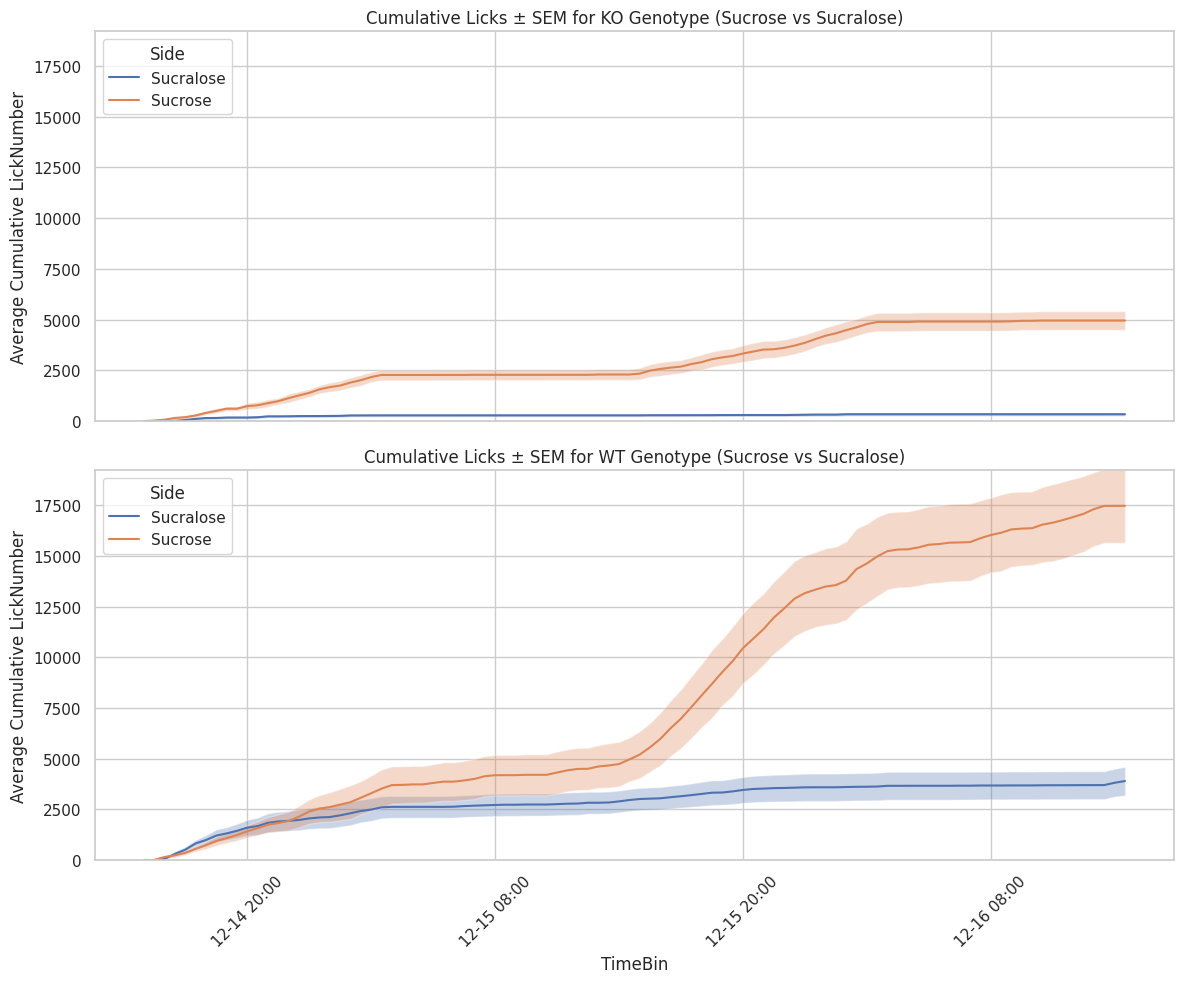

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the adjusted DataFrame
df_filtered_sides = nosepokes_bins_adjusted[nosepokes_bins_adjusted['Side'].isin(['sucrose', 'sucralose'])]

# Set up Seaborn style
sns.set(style="whitegrid")

# Get unique group names
group_names = df_filtered_sides['GroupName'].unique()

# Create subplots (one for each GroupName)
fig, axes = plt.subplots(nrows=len(group_names), ncols=1, figsize=(12, 5 * len(group_names)), sharex=True)

# Ensure axes is an array even if there's only one subplot
if len(group_names) == 1:
    axes = [axes]

# Determine the start time of the experiment
start_time = df_filtered_sides['TimeBin'].min()
end_time = df_filtered_sides['TimeBin'].max()

# Generate tick locations every 12 hours
import matplotlib.dates as mdates
hours = mdates.HourLocator(interval=12)
hours_fmt = mdates.DateFormatter('%m-%d %H:%M')

# Determine the overall maximum cumulative lick number to set a common y-axis limit
max_cum_licks = df_filtered_sides.groupby(['TimeBin', 'GroupName', 'Side'])['CumLickNumber'].mean().max() * 1.1 # Add 10% buffer


for ax, group in zip(axes, group_names):
    # Filter for this group
    df_group = df_filtered_sides[df_filtered_sides['GroupName'] == group]

    # Compute mean and SEM by TimeBin and Side for the cumulative sum
    summary = (
        df_group
        .groupby(['TimeBin', 'Side'])['CumLickNumber']
        .agg(mean='mean', sem='sem')
        .reset_index()
    )

    # Plot each side's line + SEM band
    for side in summary['Side'].unique():
        side_data = summary[summary['Side'] == side]
        ax.plot(side_data['TimeBin'], side_data['mean'], label=side.capitalize())
        ax.fill_between(
            side_data['TimeBin'],
            side_data['mean'] - side_data['sem'],
            side_data['mean'] + side_data['sem'],
            alpha=0.3
        )

    ax.set_title(f"Cumulative Licks ± SEM for {group} Genotype (Sucrose vs Sucralose)")
    ax.set_ylabel("Average Cumulative LickNumber")
    ax.legend(title="Side", loc="upper left")
    ax.xaxis.set_major_locator(hours)
    ax.xaxis.set_major_formatter(hours_fmt)
    ax.set_ylim(0, max_cum_licks)


# Final formatting
axes[-1].set_xlabel("TimeBin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
# Pivot the nosepokes_bins_adjusted DataFrame
nosepokes_pivot = nosepokes_bins_adjusted.pivot_table(
    index='TimeBin',
    columns=['GroupName', 'Side', 'AnimalName'],
    values='CumLickNumber'
)

# Sort columns by GroupName, then Side, then AnimalTag
nosepokes_pivot.sort_index(axis=1, inplace=True)

# Display the new DataFrame
nosepokes_pivot

GroupName                    KO                                      \
Side                  sucralose                                       
AnimalName          T1RKO(1)334 T1RKO(2)338 T1RKO(2)343 T1RKO(4)093   
TimeBin                                                               
2024-12-14 15:00:00         0.0         0.0         0.0         0.0   
2024-12-14 15:30:00         0.0         0.0         0.0         0.0   
2024-12-14 16:00:00        32.0         0.0         0.0         0.0   
2024-12-14 16:30:00        32.0         0.0         0.0         0.0   
2024-12-14 17:00:00       157.0        33.0        48.0        90.0   
...                         ...         ...         ...         ...   
2024-12-16 12:30:00       767.0       172.0       444.0       110.0   
2024-12-16 13:00:00       767.0       172.0       444.0       110.0   
2024-12-16 13:30:00       767.0       172.0       444.0       110.0   
2024-12-16 14:00:00       767.0       172.0       444.0       110.0   
2024-12-16 14:30:00       767.0       172.0       444.0       110.0   

GroupName                                                            \
Side                                                                  
AnimalName          T1RKO(4)337 T1RKO(4)339 T1RKO(5)092 T1RKO(8)255   
TimeBin                                                               
2024-12-14 15:00:00         0.0         0.0         0.0         0.0   
2024-12-14 15:30:00         0.0         0.0         0.0         0.0   
2024-12-14 16:00:00         0.0        18.0         0.0         0.0   
2024-12-14 16:30:00         0.0        18.0        32.0         9.0   
2024-12-14 17:00:00         0.0        18.0        63.0         9.0   
...                         ...         ...         ...         ...   
2024-12-16 12:30:00       380.0       304.0        88.0       427.0   
2024-12-16 13:00:00       380.0       304.0        88.0       427.0   
2024-12-16 13:30:00       380.0       304.0        88.0       427.0   
2024-12-16 14:00:00       380.0       304.0        88.0       427.0   
2024-12-16 14:30:00       380.0       304.0        88.0       427.0   

GroupName                                    ...           WT           \
Side                    sucrose              ...      sucrose            
AnimalName          T1RKO(1)334 T1RKO(2)338  ... Phox2b(6)234 PyyCre62   
TimeBin                                      ...                         
2024-12-14 15:00:00         0.0         0.0  ...          0.0      0.0   
2024-12-14 15:30:00         0.0         0.0  ...          0.0     54.0   
2024-12-14 16:00:00         5.0         0.0  ...          0.0     54.0   
2024-12-14 16:30:00         5.0         0.0  ...          0.0    167.0   
2024-12-14 17:00:00         5.0         0.0  ...          0.0    316.0   
...                         ...         ...  ...          ...      ...   
2024-12-16 12:30:00      4922.0      4926.0  ...      12993.0  25106.0   
2024-12-16 13:00:00      4922.0      4926.0  ...      13385.0  25268.0   
2024-12-16 13:30:00      4922.0      4926.0  ...      13513.0  25313.0   
2024-12-16 14:00:00      4922.0      4926.0  ...      13513.0  25318.0   
2024-12-16 14:30:00      4922.0      4926.0  ...      13523.0  25319.0   

GroupName                                                           \
Side                                                         water   
AnimalName          Slc7a1KO(1)279 Slc7a1KO(2)035 Cck_Vglut1(7)171   
TimeBin                                                              
2024-12-14 15:00:00            0.0            0.0              0.0   
2024-12-14 15:30:00            0.0            0.0              0.0   
2024-12-14 16:00:00          168.0           83.0              2.0   
2024-12-14 16:30:00          168.0          139.0             10.0   
2024-12-14 17:00:00          168.0          528.0             12.0   
...                            ...            ...              ...   
2024-12-16 12:30:00        12825.0        15817.0        

In [52]:
# Download the pivot table as a CSV file
nosepokes_pivot.to_csv('nosepokes_pivot_femalesT1RKO.csv')

print("The pivot table has been saved as 'nosepokes_pivot.csv'. You can download it from the files pane.")

The pivot table has been saved as 'nosepokes_pivot.csv'. You can download it from the files pane.
